# 第三章 PyTorch的基本概念

PyTorch的前身是Torch，其底层和Torch框架一样，但使用Python重新写了很多内容，不仅更加灵活，支持动态图，而且提供了Python接口，它是一个以Python环境优先的深度学习框架，不仅能够实现强大的GPU加速，同时还支持动态神经网络。为了使读者更容易理解和使用PyTorch进行深度学习训练，本章首先来介绍一下PyTorch的相关概念。

## 3.1 张量及其创建

在数学概念中，张量是一个多维数组，它是标量、向量、矩阵的高维拓展。本节介绍张量的概念，以及PyTorch中张量的几种常用创建方法。

### 3.1.1 张量及其数据类型

张量及其相关应用是近年来热门的研究话题，因为张量相对于矩阵来说能更加自然和完整地表征自然界的一些现象。张量是一个多维数组，它的每一个方向被称为模(Mode)。张量的阶数就是它的维数，一阶张量就是向量，二阶张量就是矩阵，三阶及其以上的张量统称为高阶张量。

张量是PyTorch的基本数据结构，在使用时需要表示成torch.Tensor的形式，它有8个主要的属性，如data、grad等，具体如下:

* data:被包装的张量。
* dtype:张量的数据类型。
* shape:张量的形状/维度。
* device:张量所在设备，加速计算的关键，GPU或CPU. 
* grad: data的梯度。
* grad_fn:创建张量的函数，这是自动求导的关键。 
* requires_grad:指示是否需要计算梯度。
* is_leaf:指示是否是叶子节点。 

其中，前4个属性与数据相关，后4个属性与梯度求导相关。 torch.dtype是表示torch.Tensor的数据类型的对象，PyTorch中有9种不同的数据类型，具体如下表所示。

|Data Type|dtype|CPU Tensor|GPU Tensor|
|:-:|:-:|:-:|:-:|
|32-bit floating point|torch.float32 or torch.float|torch.FloatTensor|torch.cuda.FloatTensor|
|64-bit floating point|torch.float64 or torch.double|torch. DoubleTensor|torch.cuda.DoubleTensor|
|16-bit floating point|torch.floatl6 or torch.half|torch.HalfTensor|torch.cuda.HalfTensor|
|8-bit integer(unsigned)|torch.uint8|torch.ByteTensor|torch.cuda.ByteTensor|
|8-bit integer(signed)|torch.int8|torch.CharTensor|torch.cuda.CharTensor|
|16-bit integer(signed)|torch.intl6 or torch.short|torch.ShortTensor|torch.cuda.ShortTensor|
|32-bit integer(signed)|torch.int32 or torch.int|torch.IntTensor|torch.cuda.IntTensor|
|64-bit integer(signed)|torch.int64 or torch.long|torch.LongTensor|torch.cuda.LongTensor|
|Boolean|torch.bool|torch.BoolTensor|torch.cuda.BoolTensor|

### 3.1.2 数组直接创建张量

前面我们已经初步了解了张量的概念，那么如何创建张量呢?创建张量的方法有多种，其中使用数组直接创建张量主要有以下两种方法。
* 方法1:使用torch.tensor()函数从数组直接创建张量，并查看其数据类型，具体如下:

In [2]:
import torch
import numpy as np

arr = np.ones((3, 3))
print("ndarray的数据类型：", arr.dtype)
t1 = torch.tensor(arr, dtype=torch.int64)
t2 = torch.tensor(arr, device='cpu')
print(t1,t1.dtype)
print(t2)

ndarray的数据类型： float64
tensor([[1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]]) torch.int64
tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]], dtype=torch.float64)


In [4]:
## 注意与torch.tensor的区别
x = torch.Tensor([[1, 2], [3, 4]])
print(x, x.dtype)

tensor([[1., 2.],
        [3., 4.]]) torch.float32


In [5]:
y = torch.tensor([[1, 2], [3, 4]], dtype=torch.int32)
print(y)

tensor([[1, 2],
        [3, 4]], dtype=torch.int32)


**说明：torch.Tensor()是Python类，更明确的说，是默认张量类型torch.FloatTensor()的别名，torch.tensor()仅仅是Python的函数**

* 方法2:使用torch.from_numpy()函数从NumPy创建张量。注意：通过torch.from_numpy创建的张量与原ndarray共享内存，当修改其中一个时，另一个也会被改动。

In [6]:
import torch
import numpy as np

arr = np.array([[1, 2, 3], [4, 5, 6]])
t = torch.from_numpy(arr)
print("原始数组和张量")
print(arr)
print(t)

print("\n修改张量的数值")
t[0, 2] = -1
print(arr)
print(t)

原始数组和张量
[[1 2 3]
 [4 5 6]]
tensor([[1, 2, 3],
        [4, 5, 6]])

修改张量的数值
[[ 1  2 -1]
 [ 4  5  6]]
tensor([[ 1,  2, -1],
        [ 4,  5,  6]])


In [7]:
a = t.numpy() 
print(a, a.dtype)

[[ 1  2 -1]
 [ 4  5  6]] int64


### 3.1.3 概率分布创建张量

1.从正太分布中抽取随机数创建张量

通过torch.normal()函数从给定参数的离散正态分布中抽取随几数创建张量，共有4种模式，即均值和标准差分别为标量或张量，当均值和标准差中有一个为张量，另一个为标量时，将会应用broadcast机制把标量扩展成同型张量。

torch.normal(mean, std, size, out = None)
* mean:均值
* std:标准差
* size:仅在mean和std均为标量时使用，表示创建张量的形状。

例如，mean为张量，std为张量，一一对应取mean和std中的值作为均值和标准差构成正态分布，从每个正态分布中随机抽取一个数字，具体如下:

In [8]:
import torch

mean = torch.arange(1, 5, dtype=torch.float)
std = torch.arange(1, 5, dtype=torch.float)
t = torch.normal(mean, std)
print("mean:{}\nstd:{}\n{}".format(mean, std, t))

mean:tensor([1., 2., 3., 4.])
std:tensor([1., 2., 3., 4.])
tensor([ 2.0346, -0.0260, -2.4952,  5.0617])


2.从标准正态分布中抽取随机数创建张量

可以使用torch.randn()函数和torchrandn_like()函数从标准正态分布(均值为0，标准差为1)中抽取随机数创建张量。

* torch.randn(size,out=None,dtype=None,layout=torch.strided, device=None,requires_grad=False)
* torch.randn_like (input,dtype=None, layout=None,device=None, requires_grad=False)

In [9]:
t1 = torch.randn(3, 4)
t2 = torch.randn_like(t1)
print(t1)
print(t2)

tensor([[-2.0941, -0.0075, -1.0194, -0.5861],
        [-0.9318,  1.0301,  0.4383, -0.8842],
        [ 0.8533,  0.4670,  0.3686, -0.9677]])
tensor([[ 0.8602, -0.6279,  0.3383, -1.2444],
        [ 0.1239, -0.9188,  0.4474,  1.6327],
        [-0.7215,  0.0803,  0.1485, -2.3613]])


3.从均匀分布中抽取随机数创建张量

可以使用torch.rand()函数和torchrand_like()函数从[0,1)上的均匀分布中抽取随机数创建张量。
                                       
* torch.rand(size,out=None,dtype=None, layout=torch.strided,device= None, requires_grad=False)
* torch.rand_like (input,dtype=None, layout=torch.strided,device=None,requires_grad=False)

In [10]:
t1 = torch.rand(3, 4)
t2 = torch.rand_like(t1)
print(t1)
print(t2)

tensor([[0.7207, 0.9779, 0.7110, 0.2396],
        [0.2930, 0.2490, 0.9476, 0.1354],
        [0.7033, 0.7839, 0.9393, 0.9567]])
tensor([[0.2170, 0.2389, 0.9853, 0.0971],
        [0.7613, 0.2238, 0.6917, 0.3348],
        [0.3174, 0.2606, 0.7025, 0.2599]])


### 3.1.4 几种特殊张量创建方法

1. 元素全为1的张量

* torch.ones(*size, *, out=None, dtype=None, layout=torch.strided, device=None, requires_grad=False)

In [9]:
t1 = torch.ones(2, 3)
print(t1)

tensor([[1., 1., 1.],
        [1., 1., 1.]])


In [11]:
t2 =  torch.ones_like(t1)
print(t2)

tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])


2. 元素全为0的张量

* torch.zeros(*size, *, out=None, dtype=None, layout=torch.strided, device=None, requires_grad=False)

In [12]:
t1 = torch.zeros(2, 3)
print(t1)

tensor([[0., 0., 0.],
        [0., 0., 0.]])


In [13]:
t2 = torch.zeros_like(t1)
print(t2)

tensor([[0., 0., 0.],
        [0., 0., 0.]])


3.主对角线元素全为1，其他位置元素为0的张量
* torch.eye(n, m=None, *, out=None, dtype=None, layout=torch.strided, device=None, requires_grad=False)

In [14]:
t = torch.eye(4, 4)
print(t)

tensor([[1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 0., 1.]])


## 3.2 激活函数

### 3.2.1 激活函数的必要性

在深度学习中，信号从一个神经元传入下一层神经元之前是通过线性叠加来计算的，而进入下一层神经元需要经过非线性的激活函数，继续往下传递，如此循环下去。由于这些非线性函数的反复叠加，才使得神经网络有足够的能力来抓取复杂的特征。

如果不使用非线性的激活函数，这种情况下每一层输出都是上一层输入的线性函数。无论神经网络有多少层，输出都是输入的线性函数，这样就和只有一个隐藏层的效果是一样的。这种情况相当于多层感知器(Multilayer Perceptron, MLP)

激活函数的发展经历了Sigmoid->Tanh->ReLU->Leaky ReLU等多种不同类型的激活函数及其改进结构，还有一个特殊的激活函数Softmax，它只会被用在网络中的最后一层，用来进行最后的分类和归一化。

### 3.2.2 Sigmoid激活函数

在生物学中，有一个常见的S型生长曲线函数，它就是Sigmoid函数。Sigmoid函数常被用作神经网络的阈值函数，因为它在信息科学中具备单增以及反函数单增等性质，它可以将变量映射至0~1，其公式如下:$f(x) = \frac{1}{1+e^{-x}}$

Sigmoid是几十年来应用最多的激活函数之一，它的应用范围比较广泛，值域在0~1，因此可以将其输出作为预测二值型变量取值为1的概率，有很好的概率解释性，Sigmoid激活函数在其大部分定义域内都饱和，仅仅当输入接近0时才会对输入强烈敏感。它能够控制数值的幅度，并且在深层网络中可以保持数据幅度不会出现大的变化。

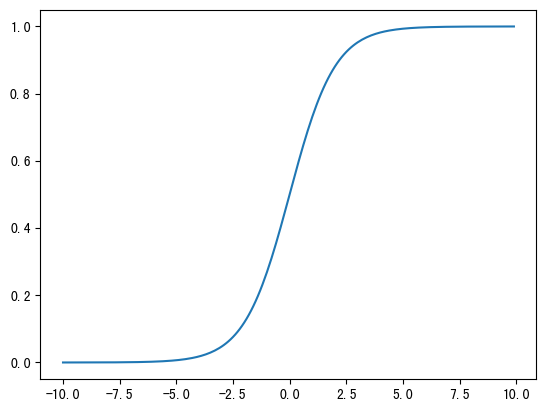

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1. / (1. + np.exp(-x))
 
def plot_sigmoid():
    x = np.arange(-10, 10, 0.1)
    y = sigmoid(x)
    plt.plot(x, y)
    plt.show()
    
if __name__ == '__main__':
    plot_sigmoid()

Sigmoid函数具有明显的优势：**首先，Sigmoid函数限定了神经元的输出范围在0~1，在一些问题中，这种形式的输出可以被看作概率取值。其次，当神经网络的损失函数取交叉熵时，S函数可用于输入数据的归一化操作，且交叉熵与Sigmoid函数的配合能够有效改善算法迭代速度慢的问题。**

### 3.2.3 Tanh激活函数

Tanh是双曲函数中的一个，Tanh()为双曲正切。在数学中，双曲正切Tanh是由基本双曲函数双曲正弦和双曲余弦推导而来的，其公式如下:

$f(x) = \frac{sinh(x)}{cosh(x)} = \frac{e^x-e^{-x}}{e^x+e^{-x}}$

在分类任务中，Tanh激活函数正逐渐取代Sigmoid激活函数成为神经网络的激活函数。根据图像可以看出，他关于原点对称，解决了Sigmoid函数中输出值都为正数的问题，而其他属性基本都与Sigmoid函数相同，具有连续性和可微性。

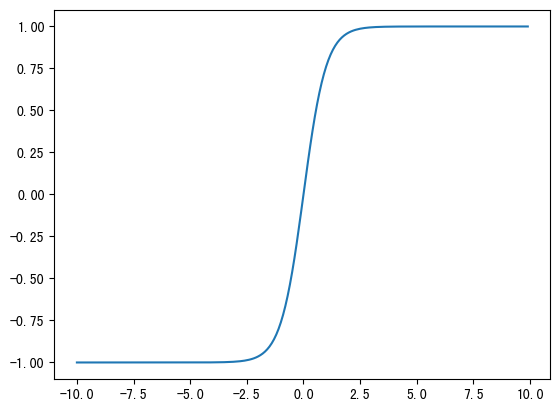

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def tanh(x):
    return (np.exp(x)-np.exp(-x))/(np.exp(x)+np.exp(-x))
 
def plot_tanh():
    x=np.arange(-10,10,0.1)
    y=tanh(x)
    plt.plot(x,y)
    plt.show()
    
if __name__ == '__main__':
    plot_tanh()

Tanh函数关于原点对称，是一个0均值的函数，这是它较之 sigmod函数有所改进的地方。Sigmoid函数的输出具有偏移现象，即输出均为大于0的实值。而Tanh的输出则均匀地分布在y轴两侧。生物神经元的激活具有稀疏性，而Tanh函数的输出结果更趋于0，从而使人工神经网络更接近生物自然状态。

### 3.2.4 ReLU激活函数

2001年，线性分段激活函数ReLU ( Rectified Linear Unit) 首次被提出，伴随深度神经网络的产生而兴起，其公式如下:$f(x)=max(0, x)$，ReLU函数的一个直观的特点就是形式简单，抑制所有小于0的输入，仅保留净激活大于0的部分。因此，当x<0时，函数的导数为0，即ReLU在x轴右侧饱和。但与Sigmoid函数和Tanh函数同时存在左右两个饱和区的情况相比，ReLU陷入单侧饱和的概率已经大大降低。另外，ReLU也是非0均值的激活函数，但是其本身具有的稀疏激活性在一定程度上可以抵消非0均值输出带来的影响。

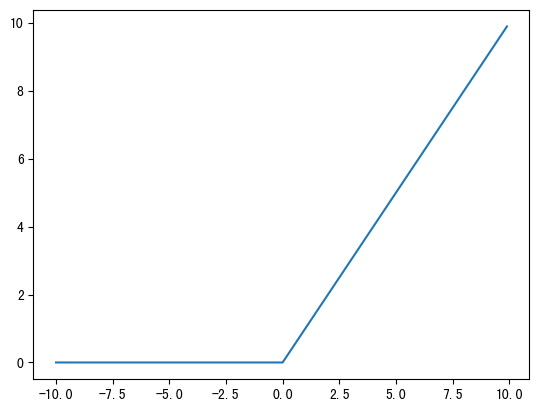

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def relu(x):
    return np.maximum(0,x)
 
def plot_relu():
    x=np.arange(-10,10,0.1)
    y=relu(x)
    plt.plot(x,y)
    plt.show()
    
if __name__ == '__main__':
    plot_relu() 

ReLU函数近年来应用较为广泛，相对于Sigmoid和Tanh，它解决了两个函数存在的致命缺陷，即梯度弥散问题:根据图像不难看出，函数在正无穷处的梯度是一个常量，而不是像前两个函数一样为0，并且由于函数组成简单，运算速度比包含指数函数的Sigmoid以及Tanh要快很多。

### 3.2.5 Leakly ReLU激活函数

当ReLU的输入值为负的时候，输出始终为0，其一阶导数也始终为0，这样会导致神经元不能更新参数，也就是神经元不学习了，这种现象叫作“神经元坏死”。为了解决ReLU函数这个缺点，在ReLU函数的负半区间引入一个泄漏(Leaky)值，所以称为Leaky ReLU函数，其公式如下:
$f(x)=max(0.01x, x)$,带泄漏修正线性单元(Leaky ReLU)函数是经典(以及广泛使用的)的ReLU激活函数的变体，该函数输出对负值输入有很小的坡度。由于导数总是不为零，这能减少静默神经元的出现，允许基于梯度的学习(虽然会很慢)，解决了ReLU函数进入负区间后，导致神经元不学习的问题。

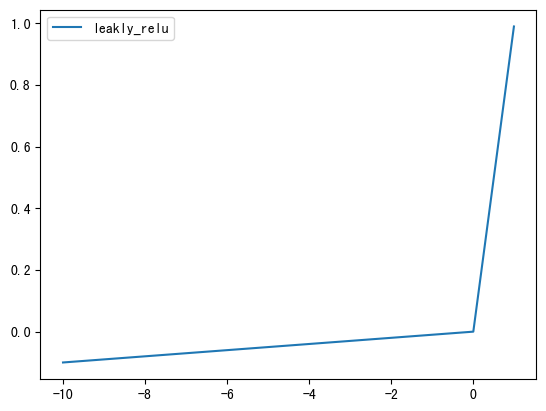

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def leakly_relu(x):
   return np.array([i if i > 0 else 0.01*i for i in x ])

def lea_relu_diff(x):
    return np.where(x > 0, 1, 0.01)

x = np.arange(-10, 1, step=0.01)
y_sigma = leakly_relu(x)
y_sigma_diff = lea_relu_diff(x)
axes = plt.subplot(111)
axes.plot(x, y_sigma, label='leakly_relu')
axes.legend()
plt.show()

### 3.2.6 其他类型激活函数

除了前面介绍的4类激活函数外，PyTorch 1.9中还有24类激活函数，如下表所示，具体用法和参数含义可以参考PyTorch官方网站的介绍文档。

|编号|激活函数|调用方法|
|:-:|:-:|:-:|
|1|nn.ELU|torch.nn.ELU(alpha=1.0, inplace=False)|
|2|nn.Hardshrink|torch.nn.Hardshrink(lambd=0.5)|
|3|nn.Hardsigmoid|torch.nn.Hardsigmoid(inplace=False)|
|4|nn.Hardtanh|torch.nn.Hardtanh(min val=-1.0, max val=1.0,...)|
|5|nn.Hardswish|torch.nn.Hardswish(inplace=False)|
|6|nn.LogSigmoid|torch.nn.LogSigmoid()|
|7|nn.MultiheadAttention|torch.nn.MultiheadAttention(embed_dim, num_heads, ... nn.PReLU|
|8|nn.PReLU|torch.nn.PReLU(num_parameters=1, init=0.25)|
|9|nn.ReLU6|torch.nn.ReLU6(inplace=False)|
|10|nn.RReLU|torch.nn.RReLU(lower-0.125, upper-0.33, inplace=False)|
|11|nn.SELU|torch.nn.SELU(inplace=False)|
|12|nn.CELU|torch.nn.CELU(alpha=1.0,inplace=False)|
|13|nn.GELU|torch.nn.GELU()|
|14|nn.SiLU|torch.nn.SiLU(inplace=False)|
|15|nn.Softplus|torch.nn.Softplus(beta=1, threshold=20)|
|16|nn.Softshrink|torch.nn.Softshrink(lambd=0.5)|
|17|nn.Softsign|torch.nn.Softsign()|
|18|nn.Tanhshrink|torch.nn,Tanhshrink|
|19|nn.Threshold|torch.nn.Threshold(threshold, value, inplace=False)|
|20|nn.Softmin|torch.nn.Softmin(dim=None)|
|21|nn.Softmax|torch.nn.Softmax(dim=None)|
|22|nn.Softmax2d|torch.nn.Softmax2d()|
|23|nn.LogSoftmax|torch.nn.LogSoftmax(dim=None)|
|24|nn.AdaptiveLogSoftmaxWithLoss|torch.nn.AdaptiveLogSoftmaxWithLoss(...)|

## 3.3 损失函数

损失函数是统计学和机器学习等领域的基础概念，它将随机事件或与其相关的随机变量的取值映射为非负实数，用来表示该随机事件的风险或损失的函数。本节介绍损失函数，以及PyTorch中的几种常用损失函数。

### 3.3.1 损失函数及选取

监督学习中的损失函数常用来评估样本的真实值和模型预测值之间的不一致程度，一般用于模型的参数估计。受到应用场景、数据集和待求解问题等因素的制约，现有监督学习算法使用的损失函数的种类和数量较多，而且每个损失函数都有各自的特征，因此从众多损失函数中选择适合求解问题最优模型的损失函数是相当困难的。

在监督学习中，损失函数表示单个样本真实值与模型预测值之间的偏差，其值通常用于衡量模型的性能。现有的监督学习算法不仅使用了损失函数，而且求解不同应用场景的算法会使用不同的损失函数。研究表明，即使在相同场景下，不同的损失函数度量同一样本的性能时也存在差异。可见，损失函数的选用是否合理直接决定着监督学习算法预测性能的优劣。

在实际问题中，损失函数的选取会受到许多约束，如机器学习算法的选择、是否有离群点、梯度下降的复杂性、求导的难易程度以及预测值的置信度等。目前，没有一种损失函数能完美处理所有类型的数据。在同等条件下，模型选取的损失函数越能扩大样本的类间距离、减小样本的类内距离，模型预测的精确度就越高。实践表明，在同一模型中，与求解问题数据相匹配的损失函数往往对提升模型的预测能力起着关键作用。因此，如果能正确理解各种损失函数的特性，分析它们适用的应用场景，针对特定问题选取合适的损失函数，就可以进一步提高模型的预测精度。

损失函数的标准数学形式不仅种类多，而且每类损失函数又在其标准形式的基础上演化出了许多演化形式。0-1损失函数是最简单的损失函数，在其基础上加入参数控制损失范围，形成感知器损失函数;加入安全边界，演化为铰链损失函数。可见，损失函数的发展不是孤立的，而是随着应用研究的发展进行变革的。在PyTorch中，损失函数通过torch.nn包实现调用。

### 3.3.2 L1范数损失函数

L1范数损失即L1Loss，计算方法比较简单，原理就是取预测值和真实值的绝对误差的平均数，计算模型预测输出output和目标target之差的绝对值，可选返回同维度的张量或者一个标量，计算公式如下:$loss(x,y)=\frac{1}{N}\sum_{i=1}^{N}|x-y|$。

模型调用方法如下:torch.nn.L1Loss(size_average=None,reduce=None,reduction='mean') 

参数说明:
* size_average: 当reduce=True时有效。为True时，返回的loss为平均值;为False时，返回各样本的loss数值之和。
* reduce:返回值是否为标量，默认为True。

In [21]:
import torch

loss = torch.nn.L1Loss(reduction="sum")
pred = torch.tensor([1.0, 2.0, 3.0, 4.0])
target = torch.tensor([4.0, 5.0, 6.0, 7.0])
output = loss(pred, target)
print(output)

tensor(12.)


两个输入类型必须一致，reduction是损失函数的一个参数，有3个值:none返回的是一个向量(batch_size), sum返回的是和， mean返回的是均值。上面的例子用不同参数的话，返回值分别为: tensor([3.,3.,3.,3.])、tensor(3.)、tensor(12.).

### 3.3.3 均方误差损失函数

均方误差损失即MSELoss，计算公式是预测值和真实值之间的平方和的平均数，计算模型预测输出output和目标target之差的平方，可选返回同维度的张量或者一个标量，计算公式如下:$loss(x,y)=\frac{1}{N}\sum_{i=1}^N|x-y|^2$

模型调用方法如下:torch.nn.MSELoss(reduce=True,size_average=True,reduction='mean') 
参数说明:
* reduce:返回值是否为标量，默认为True。
* size_average:当reduce=True时有效。为True时，返回的loss为平均值;为False时，返回各样本的loss数值之和。

In [23]:
import torch

pred = torch.tensor([1.0, 2.0, 3.0, 4.0])
target = torch.tensor([4.0, 5.0, 6.0, 7.0])

loss_fn = torch.nn.MSELoss(reduction="mean")
loss = loss_fn(pred, target)
print(loss)

tensor(9.)


这里注意一下两个入参:reduce=False，返回向量形式的 loss; reduce=True，返回标量形式的loss。size_average=True,返回loss.mean();如果size_average=False，则返回loss.sum().默认情况下，两个参数都为True。

### 3.3.4 交叉熵损失函数

交叉熵损失即CrossEntropyLoss，该损失函数结合了nn.LogSoftmax()和nn.NLLLoss()两个函数，在做分类训练的时候是非常有用的。首先介绍一下交叉熵的概念，它是用来判定实际输出与期望输出的接近程度，例如分类训练的时候，如果一个样本属于第K类，那么这个类别所对应的输出节点的输出值应该为1，而其他节点的输出都为0，即[0,0,1,0,0,0]，也就是样本的标签，它是神经网络最期望的输出。也就是说，用它来衡量网络的输出与标签的差异，利用这种差异通过反向传播去更新网络参数。

交叉熵主要刻画的是实际输出概率与期望输出概率的距离，也就是交叉熵的值越小，两个概率分布就越接近，假设概率分布p为期望输出，概率分布q为实际输出，计算公式如下:$H(p,q)=-\sum_{x}p(x)*logq(x)$

模型调用方法如下:
torch.nn.CrossEntropyLoss (weight=None,size_average=None,ignore_index=-100,reduce=None,reduction='mean')

* weight(tensor):n个元素的一维张量，分别代表n类的权重，如果训练样本很不均衡的话，非常有用，默认值为None。
* size_average:当reduce=True时有效。为True时，返回的loss为平均值；为False时，返回各样本的loss数值之和。
* ignore_index：忽略某一类别，不计算其loss,并且在采用size_average时，不会计算那一类的loss数值。
* reduce:返回值是否为标量，默认为True。

In [24]:
import torch

entroy = torch.nn.CrossEntropyLoss()
pred = torch.Tensor([[-0.1181, -0.3682, -0.2209]])
target = torch.tensor([0])

output = entroy(pred, target)
print(output)

tensor(0.9862)


### 3.3.5 余弦相似度损失

余弦相似度损失目的是让两个向量尽量相近。注意这两个向量都是有梯度的，计算公式如下：

$loss(x, y)=\begin{cases}
1-cos(x1,x2) & y=1\\
max(0, cos(x1,x2)-margin) & y=-1
\end{cases}
$，其中margin可以取[-1,1]，但是建议取0~0.5。

模型调用方法如下：torch.nn.CosineEmbeddingLoss(margin=0.0,reduction='mean'

In [25]:
import torch

a = torch.tensor([1.0, 2.0, 3.0, 4.0])
b = torch.tensor([4.1, 6.1, 7.1, 8.1])

similarity = torch.cosine_similarity(a, b, dim=0)
loss = 1 - similarity
print(loss)

tensor(0.0199)


### 3.3.6 其他损失函数

除了前面介绍的4类损失函数外，PyTorch 1.9中还有16类损失函数，如下表所示，具体用法和参数含义可以参考PyTorch官方网站的介绍文档。

|编号|损失函数|函数说明|
|:-:|:-:|:-:|
|1|nn.CTCLoss|连接时序分类损失|
|2|nn.NLLLoss|负对数似然损失|
|3|nn.PoissonNLLLoss|泊松负对数似然损失|
|4|nn.GaussianNLLLoss|高斯负对数似然损失|
|5|nn.KLDivLoss|KL散度损失|
|6|nn.BCELoss|二进制交叉熵损失|
|7|nn.BCEWithLogitsLoss|逻辑二进制交叉熵损失|
|8|nn.MarginRankingLoss|间隔排序损失|
|9|nn.HingeEmbeddingLoss|铰链嵌入损失|
|10|nn.MultiLabelMarginLoss|多标签分类损失|
|11|nn.SoftMarginLoss|两分类逻辑损失|
|12|nn.MultiLabelSoftMarginLoss|多标签逻辑损失|
|13|nn.SmoothLILoss|平滑L1损失|
|14|nn.MultiMarginLoss|多类别分类损失|
|15|nn.TripletMarginLoss|三元组损失|
|16|nn.TripletMarginWithDistanceLoss|距离三元组损失|

## 3.4 优化器

优化器就是在深度学习反向传播过程中，指引损失函数的各个参数往正确的方向更新合适的大小，使得更新后的各个参数让损失函数（目标函数)值不断逼近全局最小。本节介绍优化器，以及PyTorch中的几种常用优化器。

### 3.4.1 梯度及梯度下降

梯度是微积分中一个很重要的概念，在单变量的函数中，梯度其实就是函数的微分，代表着函数在某个给定点的切线的斜率。在多变量函数中，梯度是一个向量，向量有方向，梯度的方向就指出了函数在给定点的上升最快的方向。

例如，如果你需要从山上下来，要选择下山的路径，就需要利用周围的环境信息去寻找。这个时候，可以利用梯度下降算法来帮助自己下山，以当前所处的位置为基准，寻找这个位置最陡峭的地方，然后朝着下山的方向走，每走一段距离，都反复采用同一个方法。

梯度下降的基本过程就和下山的场景类似，如下图所示。首先，我们有一个可微分的函数。这个函数就代表着一座山，我们的目标就是找到这个函数的最小值。对应到函数中，就是找到给定点的梯度，然后朝着梯度相反的方向，就能让函数值下降得最快，因为梯度的方向就是函数值变化最快的方向。所以，我们重复利用这个方法反复求取梯度，最后就能到达局部的最小值，这就类似于我们下山的过程。梯度下降的公式：$\theta_i=\theta_i-\alpha \frac{\partial J(\theta)}{\partial \theta_i}$。

α在梯度下降算法中被称作为学习率或步长，意味着我们可以通过它来控制每一步走的距离，不能太大，也不能太小，太小的话可能导致迟迟走不到最低点，太大的话会导致错过最低点。

梯度前加一个负号，就意味着朝着梯度相反的方向前进。梯度的方向实际就是函数在此点上升最快的方向，而我们需要朝着下降最快的方向走，自然就是负的梯度的方向，所以此处需要加上负号。

![梯度下降](./data/img1.jpeg)

常见的梯度下降算法有：全梯度下降（Full Gradient Descent)算法、随机梯度下降(Stochastic Gradient Descent, SGD)算法、随机平均梯度下降（Stochastic Average Gradient Descent)算法、小批量梯度下降(Mini-Batch Gradient Descent)算法。

### 3.4.2 随机梯度下降算法

随机梯度下降算法源于1951年Robbins和Monro提出的随机逼近，最初被应用于模式识别和神经网络。这种方法在迭代过程中随机选择一个或几个样本的梯度来替代总体梯度，从而大大降低了计算复杂度。1958年，Rosenblatt等研制出的感知器采用了随机梯度下降法的思想，即每轮随机选取一个误分类样本，求其对应损失函数的梯度，再基于给定的步长更新参数。1986年，Rumelhart等分析了多层神经网络的误差反向传播算法，该算法每次按顺序或随机选取一个样本来更新参数，它实际上是小批量梯度下降法的一个特例。

批量梯度下降算法在梯度下降时，每次迭代都要计算整个训练数据上的梯度，当遇到大规模训练数据时，计算资源需求多，数据通常也会非常冗余。随机梯度下降算法则把数据拆成几个小批次样本，每次只随机选择一个样本来更新神经网络参数。实验表明，每次使用小批量样本，虽然不足够反映整体数据的情况，但却很大程度上加速了神经网络的参数学习过程，并且不会丢失太多准确率。

对比批量梯度下降法，假设从一批训练样本$n$中随机选取一个样本$i_S$。模型参数为$W$,代价函数为$J(W)$,梯度为$\Delta J(W)$,学习率为$\eta_t$,则使用随机梯度下降法更新参数表达式为：$W_{t+1} = W_t-\eta_tg_t$，其中，$g_t=\Delta J_{i_S}(W_t;X^{i_S})$，$i_S\in 1, 2, ..., n$表示随机选择的一个梯度方向，$W_t$表示t时刻的模型参数。$E(g_t)=\Delta J(W_t)$。这里虽然引入了随机性和噪声，但期望仍然等于正确的梯度下降。

**算法优点：虽然SGD需要走很多步的样子，但是对梯度的要求很低（计算梯度快)。而对于引入噪声，大量的理论和实践工作证明，只要噪声不是特别大SGD都能很好地收敛。应用大型数据集时，训练速度很快。比如每次从百万数据样本中取几百个数据点，计算一个SGD梯度，更新一下模型参数。相比于标准梯度下降法的遍历全部样本，每输入一个样本更新一次参数，要快得多。**

**算法缺点：SGD在随机选择梯度的同时会引入噪声，使得权值更新的方向不一定正确。此外，SGD也没能单独克服局部最优解的问题。**

### 3.4.3 标准动量优化算法

Momentum算法则将动量运用到神经网络的优化中，用累计的动量来替代真正的梯度，计算负梯度的“加权移动平均”来作为参数的更新方向，其参数更新表达式为：$\Delta \theta_t = \rho \Delta \theta_{t-1}-\alpha g_t$。

其中$\rho$为动量因子，通常设为0.9，$\alpha$为学习率。这样，每个参数的实际更新差值取决于最近一段时间内梯度的加权平均值，当某个参数在最近一段时间内的梯度方向不一致时，其真实的参数更新幅度变小；相反，当在最近一段时间内的梯度方向都一致时，其真实的参数更幅度变大，起到加速作用，
相比SGD,能更快地到达最优。

**动量主要解决SGD的两个问题：一是随机梯度的方法（引入的噪声)；二是Hessian矩阵病态问题（可以理解为SGD在收敛过程中和正确梯度相比来回摆动比较大的问题)。简单理解：由于当前权值的改变会受到上一次权值改变的影响，类似于小球向下滚动的时候带上了惯性。这样可以加快小球向下滚动的速度。**

### 3.4.4 AdaGrad算法

在标准的梯度下降算法中，每个参数在每次迭代时都使用相同的学习率，AdaGrad算法则改变了这一传统思想，由于每个参数维度上收敛速度都不相同，因此根据不同参数的收敛情况分别设置学习率。AdaGrad算法借鉴正则化思想，每次迭代时自适应地调整每个参数的学习率，在进行第次迭代时，先计算每个参数梯度平方的累计值，其表达式为：$G_t = \sum_{i=1}^tg_i\cdot g_i$，其中$\cdot$为按元素乘积，$g_t$是第t次迭代时的梯度。然后计算参数的跟新差值，表达式为：$\Delta \theta_t = -\frac{\alpha}{\sqrt{G_t+\varepsilon}}\cdot g_t$，其中$\alpha$是初始学习率，$\varepsilon$是为了保持数值稳定性而设置的非常小的常数。

**在AdaGrad算法中，如果某个参数的偏导数累积比较大，其学习率相对较小；相反，如果其偏导数累积较小，其学习率相对较大。但整体是随着迭代次数的增加，学习率逐渐缩小。**

### 3.4.5 RMSProp算法

RMSProp算法对AdaGrad算法进行了改进，在AdaGrad.算法中，由于学习率逐渐减小，在经过一定次数的迭代依然没有找到最优点时，便很难再继续找到最优，点，RMSProp算法则可在有些情况下避免这种缺点。RMSProp算法首先计算每次迭代梯度$g_t$，平方的指数衰减移动平均：$G_t = \beta G_{t-1}+(1-\beta)g_t\cdot g_t$。其中$\beta$为衰减率，然后用和AdaGrad同样的方法计算参数更新差值。**从表达式中可以看出，RMSProp算法的每个学习参数的衰减趋势既可以变小又可以变大。RMSProp算法在经验上已经被证明是一种有效且实用的深度神经网络优化算法，目前它是深度学习从业者经常采用的优化方法之一。**

### 3.4.6 Adam算法

Adam算法即自适应动量估计算法，是Momentum算法和RMSProp算法的结合，不但使用动量作为参数更新方向，而且可以自适应调整学习率。Adam算法一方面计算梯度平方的指数加权平均（和RMSProp算法类似），另一方面计算梯度的指数加权平均（和Momentum算法类似），其表达式为：
$M_t = \beta M_{t-1}+(1-\beta_1)g_t, G_t = \beta G_{t-1}+(1-\beta_2)g_t\cdot g_t$，其中$\beta_1$和$\beta_2$分别为两个移动平均的衰减率，Adam算法的参数跟新差值为：$\Delta \theta_t=-\frac{\alpha}{\sqrt{G_t+\varepsilon}}\cdot M_t$。**Adam算法集合了Momentum算法和RMSProp算法的优，点， 因此相比之下，Adam能更快、更好地找到最优点，迅速收敛。**

## 3.5 动手练习：PyTorch优化器比较

为了让读者更好地理解和使用深度学习中的优化器，本节介绍PyTorch优化器的应用案例。

**1.说明**

PyTorch中的优化器较多，读者可能不知道如何选择，本例通过模型比较PyTorch中的SGD、Momentum、AdaGrad、RMSProp、Adam五种主要优化器的优劣，从而有助于选择合适的优化器

**2.步骤**

(1) 导入相关的第三方库

In [1]:
import os
import torch
import torch.nn
import torch.utils.data as Data

import matplotlib
import matplotlib.pyplot as plt

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
matplotlib.rcParams['font.sans-serif'] = ['SimHei']

(2) 准备建模数据

In [5]:
x = torch.unsqueeze(torch.linspace(-1, 1, 500), dim=1)
y = x.pow(3)

(3) 设置参数

In [6]:
LR = 0.01
batch_size = 15
epoches = 5
torch.manual_seed(10)

(4) 设置数据加载器

In [7]:
dataset = Data.TensorDataset(x, y)
loader = Data.DataLoader(dataset=dataset,batch_size=batch_size,shuffle=True,num_workers=2)

(5) 搭建神经网络框架

In [8]:
class Net(torch.nn.Module):
    def __init__(self, n_input, n_hidden, n_output):
        super(Net, self).__init__()
        self.hidden_layer = torch.nn.Linear(n_input, n_hidden)
        self.output_layer = torch.nn.Linear(n_hidden, n_output)

    def forward(self, input):
        x = torch.relu(self.hidden_layer(input))
        output = self.output_layer(x)
        return output

(6) 训练模型并输出折线图

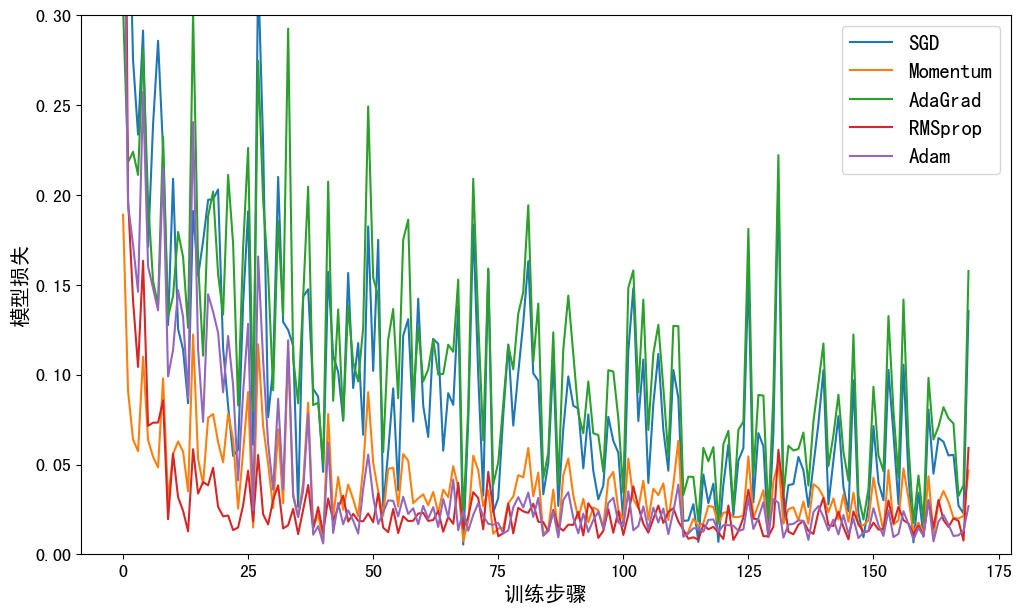

In [9]:
def train():
    net_SGD = Net(1, 10, 1)
    net_Momentum = Net(1, 10, 1)
    net_AdaGrad = Net(1, 10, 1)
    net_RMSprop = Net(1, 10, 1)
    net_Adam = Net(1, 10, 1)
    nets = [net_SGD, net_Momentum, net_AdaGrad, net_RMSprop, net_Adam]

    ## 定义优化器
    optimizer_SGD = torch.optim.SGD(net_SGD.parameters(), lr=LR)
    optimizer_Momentum = torch.optim.SGD(net_Momentum.parameters(), lr=LR, momentum=0.6)
    optimizer_AdaGrad = torch.optim.Adagrad(net_AdaGrad.parameters(), lr=LR, lr_decay=0)
    optimizer_RMSprop = torch.optim.RMSprop(net_RMSprop.parameters(), lr=LR, alpha=0.9)
    optimizer_Adam = torch.optim.Adam(net_Adam.parameters(), lr=LR, betas=(0.9, 0.99))
    optimizers = [optimizer_SGD, optimizer_Momentum, optimizer_AdaGrad, optimizer_RMSprop, optimizer_Adam]

    ## 定义损失函数
    loss_function = torch.nn.MSELoss()
    losses = [[], [], [], [], []]

    for epoch in range(epoches):
        for step, (batch_x, batch_y) in enumerate(loader):
            for net, optimizer, loss_list in zip(nets, optimizers, losses):
                pred_y = net(batch_x)
                loss = loss_function(pred_y, batch_y)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                loss_list.append(loss.data.numpy())

    plt.figure(figsize=(12,7))
    labels = ['SGD', 'Momentum', 'AdaGrad', 'RMSprop', 'Adam']
    for i, loss in enumerate(losses):
        plt.plot(loss, label=labels[i])
        
    plt.legend(loc='upper right',fontsize=15)
    plt.tick_params(labelsize=13)
    plt.xlabel('训练步骤',size=15)
    plt.ylabel('模型损失',size=15)
    plt.ylim((0, 0.3))
    plt.show()

if __name__ == "__main__":
    train()

本实例比较了PyTorch中的主要优化器算法，其中RMSProp、Momentum两种优化器的模型损失相对较小，表现最好。